# PA005 - High Value Customer Identification (Insiders)

# SOLUTION PLANNING

"All in one place" is an online retail store that sells second-hand products from various brands at lower prices.

With just over a year of operation, the marketing team noticed that some customers from their base purchase more expensive products more frequently, contributing significantly to the company's revenue.

Based on this insight, the marketing team decided to launch a loyalty program for the top customers in their base, named Insiders. However, the marketing team lacks the necessary knowledge to select the participating customers for this program.

As a result, this task was assigned to the company's data team, where a solution that ultimately provides a list of customers to be invited to participate in the Insiders program should be developed. Additionally, a report answering the following questions should be delivered:

1. Who are the eligible individuals to participate in the program?
   - Faturamento:
        - Alto ticket medio
        - Alto LTV
        - Baixa recencia
        - Baixa probabilidade de churn
        - Alta previsao LTV
        - Alta propensao de compra

    - Custo:
        - Baixa taxa de devolucao

   - Experiencia de Compra
        - Media alta das avaliacoes    

2. How many customers will be part of the group?
   - Numero total de clientes
   - % do grupo insiders
    
3.  What are the main characteristics of these customers?
    - Escrever caracteristicas do cliente:
      - Idade
      - Localizacao
       
    - Escrever caracteristicas do consumo:
      - Atributos da clusterizacao

4. What percentage of the revenue comes from the selected group?
    - Faturamento total do ano
    - Faturamento do grupo Insiders

5. What is the revenue expectation for this group in the upcoming months?
    - LTV do grupo Insiders
    - Analise de Cohort
    
6. What are the conditions for someone to be eligible for the group?
   - Definir a periodicidade ( 1 month, 2 month, etc.). 
   - A pessoa precisa ser similar com uma outra pessoa do grupo.

7. What are the conditions for someone to be removed from the group?
   - Definir a periodicidade ( 1 month, 2 month, etc.). 
   - A pessoa precisa ser desimilar com uma outra pessoa do grupo.
   
8. What assurance is there that the group is better than the rest of the base?
   - Teste A/B.
   - Teste A/B Bayesiano.
   - Teste de hipotese.

9. What actions can the marketing team take to increase revenue?
   - Desconto
   - Preferencia de Compra
   - Visitar empresa

**SOLUTION PLANNING**

1 - Input:
    Business Problem: Hight value customers identification and selection in order to join a loyalty program.
    Dataset: sales datas from an e-commerce, collected trough an one year period.

2 - Output:
    List containing the customer identification and if they are eligible or not to the loyalty program.
    Report, answering the business questions and explaining how the selection was made.
    
3 - Tasks
    - Who are the eligible individuals to participate in the program?
        Understanding of what elegible means and what are the most valuable customer.
        
        
    - How many customers will be part of the group?
        
        
    - What are the main characteristics of these customers?
        
    
    - What percentage of the revenue comes from the selected group?
        
    
    - What is the revenue expectation for this group in the upcoming months?
        
    
    - What are the conditions for someone to be eligible for the group?
        
    
    - What are the conditions for someone to be removed from the group?
        
    
    - What assurance is there that the group is better than the rest of the base?
        
    
    - What actions can the marketing team take to increase revenue?
        


# 0 - IMPORTS </font>

In [40]:
# Data Maniputalion and Data Analysis
import pandas  as pd
import numpy   as np
import seaborn as sns

from matplotlib import pyplot  as plt
from plotly     import express as px

# ML Algorithms
import umap.umap_ as umap

from sklearn import cluster as c
from sklearn import metrics as mt
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# Loading Images
from IPython.display         import Image, display
from IPython.core.display    import HTML


## 0.1 - Helper Functions

In [ ]:
def jupyter_settings():
    %matplotlib inline
    %pylab inline
    
    plt.style.use( 'bmh' )
    plt.rcParams['figure.figsize'] = [25,12]
    plt.rcParams['font.size'] = 24
    
    display( HTML( '<style>.container {width:100% !important; }</style>') )
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option( 'display.expand_frame_repr', False )
    
    sns.set()
jupyter_settings()

# 1 - DATAS

## 1.1 - Loading the Datas

In [41]:
df = pd.read_csv("../data/raw/Ecommerce.csv")

# drop extra column

df = df.drop( columns=['Unnamed: 8'], axis=1)


In [42]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,29-Nov-16,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,29-Nov-16,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,29-Nov-16,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,29-Nov-16,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,29-Nov-16,3.39,17850.0,United Kingdom


## 1.2 - DATA DESCRIPTIVE

### 1.1.1 - RENAME COLUMNS

In [43]:
df1 = df.copy()

In [44]:
cols_new = ['invoice_no','stock_code','description','quantity','invoice_date','unit_price','customer_id','country']
df1.columns = cols_new

### 1.2.2 - DATA DIMENSIONS

In [45]:
print('Number of columns: {}'.format( df1.shape[1] ) )
print('Number of rows: {}'.format( df1.shape[0] ) )

Number of columns: 8
Number of rows: 541909


### 1.2.3 - DATA TYPES

In [46]:
df1.dtypes

invoice_no       object
stock_code       object
description      object
quantity          int64
invoice_date     object
unit_price      float64
customer_id     float64
country          object
dtype: object

### 1.2.4 - CHECK NA VALUES

In [47]:
df1.isna().sum()

invoice_no           0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135080
country              0
dtype: int64

### 1.2.5 - REPLACE NA VALUES

In [48]:
# Remove NA
df1 = df1.dropna( subset=['customer_id', 'customer_id'] )
print( 'Removed data"{:2f}%'.format( 1 - (df1.shape[0] / df.shape[0] ) ) )

Removed data"0.249267%


### 1.2.6 - CHANGE DTYPES

In [49]:
df1.dtypes

invoice_no       object
stock_code       object
description      object
quantity          int64
invoice_date     object
unit_price      float64
customer_id     float64
country          object
dtype: object

In [50]:
df1[ 'invoice_date'] = pd.to_datetime( df1['invoice_date'], format='%d-%b-%y')

df1['customer_id'] = df1['customer_id'].astype( int )

In [51]:
 df1.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2016-11-29,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2016-11-29,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2016-11-29,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2016-11-29,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2016-11-29,3.39,17850,United Kingdom


### <font color='red'>1.2.7 - DESCRIPTIVE STATISTICS </font>

# 2 - FATURE ENGINEERING

In [52]:
df2 = df1.copy()

In [53]:
# data reference
df_ref = df2.drop( ['invoice_no','stock_code','description','quantity','invoice_date','unit_price','country'],axis=1).drop_duplicates(ignore_index=True)

In [54]:
df_ref.head()

,customer_id
0,17850
1,13047
2,12583
3,13748
4,15100


In [55]:
# Gross Revenue
df2['gross_revenue'] = df2['quantity'] * df2['unit_price']

# Money
df_money = df2[['customer_id', 'gross_revenue']].groupby('customer_id').sum().reset_index()
df_ref = pd.merge( df_ref, df_money, on='customer_id', how='left')

# Recency
df_recency = df2[['customer_id', 'invoice_date']].groupby('customer_id').max().reset_index()
df_recency['recency_days'] = (df2['invoice_date'].max() - df_recency['invoice_date']).dt.days
df_recency = df_recency[['customer_id','recency_days']].copy()
df_ref = pd.merge( df_ref, df_recency, on='customer_id', how='left')

# Frequency
df_freq = df2[['customer_id', 'invoice_no']].drop_duplicates().groupby('customer_id').count().reset_index()
df_ref = pd.merge(df_ref, df_freq, on='customer_id', how='left')

# Avg Ticket
df_avg_ticket = df2[['customer_id','gross_revenue']].groupby('customer_id').mean().reset_index().rename( columns={'gross_revenue':'avg_ticket'})
df_ref = pd.merge( df_ref, df_avg_ticket, on='customer_id', how='left')

# <font color='red'> 3 - DATA FILTERING </font>

In [56]:
df3 = df_ref.copy()

# <font color='red'> 4 - EDA </font>

In [57]:
df4 = df3.copy()

# <font color='red'> 5 - DATA PREPARATION </font>

In [58]:
df5 = df4.copy()

# <font color='red'> 6 - FEATURE SELECTION </font>

In [59]:
df6 = df5.copy()

# 7 - FINE TUNING

In [60]:
X = df6.drop( columns=['customer_id'])

In [61]:
cluster = [2,3,4,5,6,7]

## 7.1 -  K-Means within-cluster sum of square (WSS)

In [62]:
# O K-Means vai definir, aleatoriamente, n pontos centrais no meu conjunto de dados. A quantidade de pontos e definida pelo usuario, como sendo o numero de cluster desejado.
# A partir da definicao dos pontos centrais, o K-Means vai atribuir cada ponto ao centroide mais proximo, calculando a distancia euclidiana entre o ponto e o centroide.
# Para cada grupo formado, o algoritmo vai recalcular o centroide como sendo a media de todos os pontos pertencentes aquele grupo. Movendo o centroide para uma posicao que minimiza a soma dos quadrados das distancias. E esse processo se 
# repete ate que os centroides nao tenham uma mudanca significativa em suas posicoes.
# Para a Metrica WSS:
    # O K-Means vai calcular a distancia entre cada um dos pontos em relacao ao ponto central para cada um dos clusters, somar esses valores, gerando um valor total para cada cluster. O WSS eh dado somando esse valor total para todos 
    # clusters. E entende-se que o numero de cluster ideal eh aquele cujo apresenta uma diferenca maior no valor da metrica WSS.
# Esta metrica nao leva em consideracao a distancia entre os clusters, o que pode vir a ser um problema, uma vez que podemos ter clusters muito proximos, o que torna dificil a separacao.

In [63]:

# URL da imagem
url_imagem = '../reports/figures/wss.png'  # Substitua pela URL da sua imagem

# Exibe a imagem no notebook
display(Image(url=url_imagem))

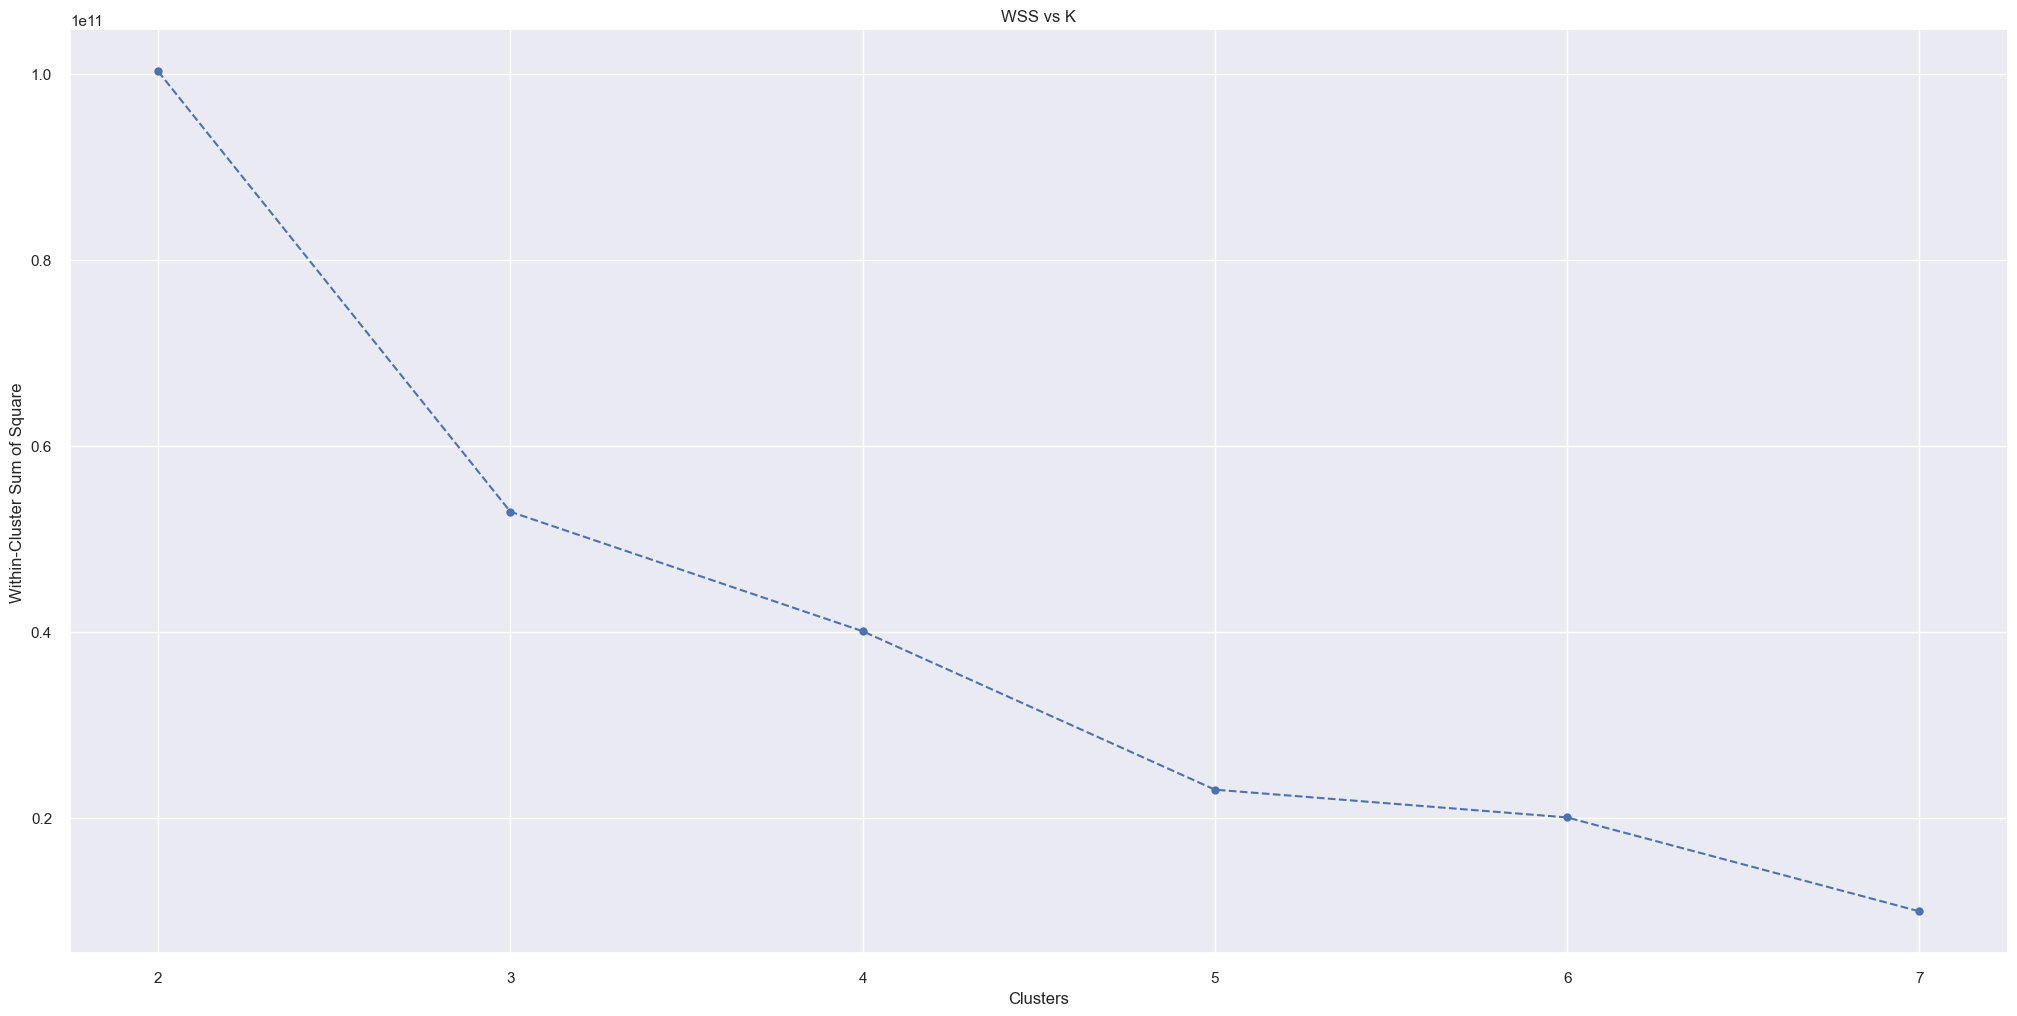

In [64]:
wss = []
for k in cluster:
    # Model Definition
    kmeans = c.KMeans(init='random', n_clusters=k, n_init=10, max_iter=300, random_state=42)
    
    # Model Training
    kmeans.fit( X )

    # Validation
    wss.append( kmeans.inertia_ ) 

# plot wss
plt.plot( cluster, wss, linestyle='--', marker='o', color='b'); 
plt.xlabel('Clusters'); 
plt.ylabel('Within-Cluster Sum of Square'); 
plt.title('WSS vs K'); 

c:\Users\perot\anaconda3\envs\pa_clustering\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

c:\Users\perot\anaconda3\envs\pa_clustering\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

c:\Users\perot\anaconda3\envs\pa_clustering\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

c:\Users\perot\anaconda3\envs\pa_clustering\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

c:\Users\perot\anaconda3\envs\pa_clu

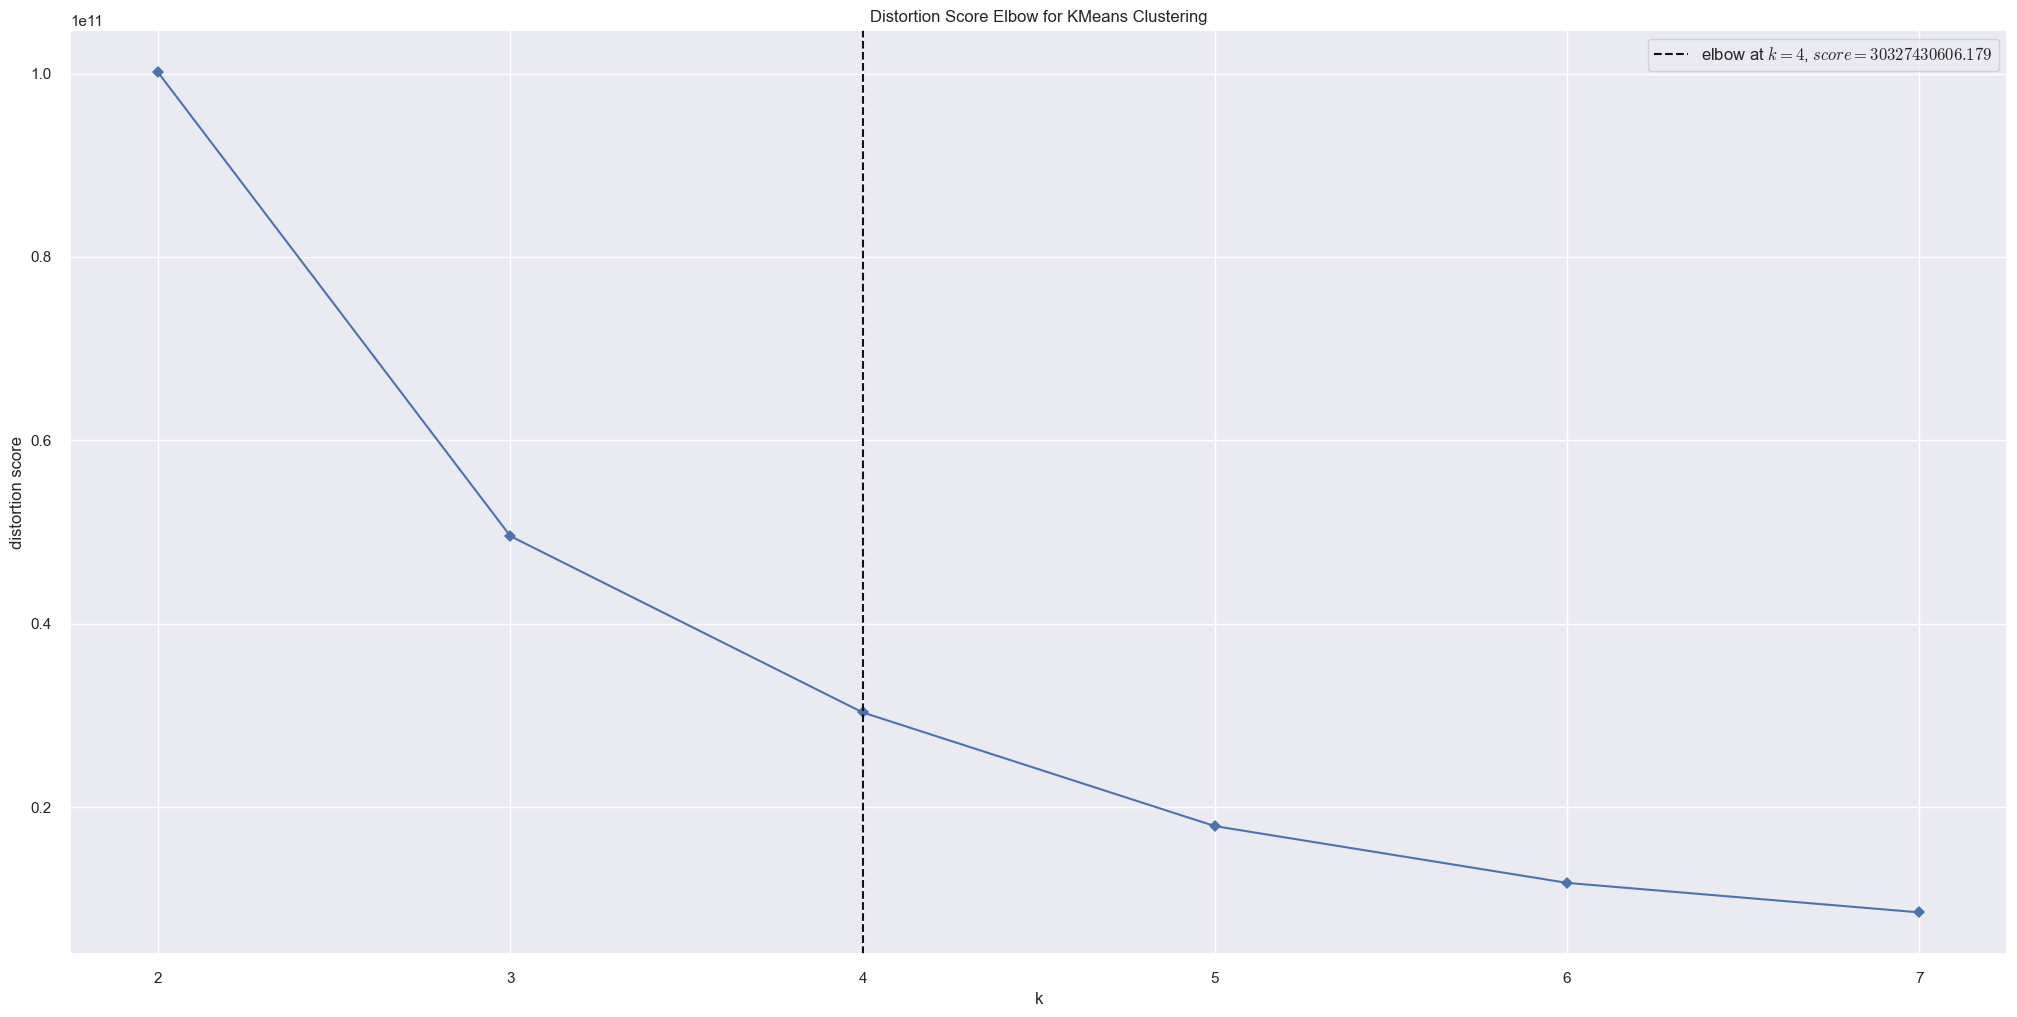

In [65]:
kmeans = KElbowVisualizer( c.KMeans(), k=cluster, timings=False );
kmeans.fit( X );
kmeans.show();

## 7.2 -  Silhouette Score

In [66]:
#O Silhouette Score é uma métrica de avaliação de clusters que mede o quão bem os pontos de dados estão agrupados. Ele leva em consideração a distância média entre os pontos dentro do mesmo cluster (a) e a distância média entre os pontos de um cluster para o cluster
#mais próximo diferente dele (b). Esses valores são então usados para calcular um valor de silhueta para cada ponto de dados.

#URL da imagem
url_imagem = '../reports/figures/ss_2.png'  # Substitua pela URL da sua imagem

# Exibe a imagem no notebook
display(Image(url=url_imagem))

In [67]:
# O valor de S(i) varia de -1 a 1. Quanto mais próximo o valor estiver de 1, melhor o ponto está agrupado. Se o valor for próximo a 0, significa que o ponto está próximo à fronteira entre dois clusters. Se o valor for negativo, indica que o ponto pode ter sido atribuído ao 
# cluster errado.

# O Silhouette Score global para todos os pontos de dados é a média dos valores de silhueta individuais para todos os pontos:
# URL da imagem
url_imagem = '../reports/figures/ss_3.png'  # Substitua pela URL da sua imagem

# Exibe a imagem no notebook
display(Image(url=url_imagem))

c:\Users\perot\anaconda3\envs\pa_clustering\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

c:\Users\perot\anaconda3\envs\pa_clustering\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

c:\Users\perot\anaconda3\envs\pa_clustering\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

c:\Users\perot\anaconda3\envs\pa_clustering\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

c:\Users\perot\anaconda3\envs\pa_clu

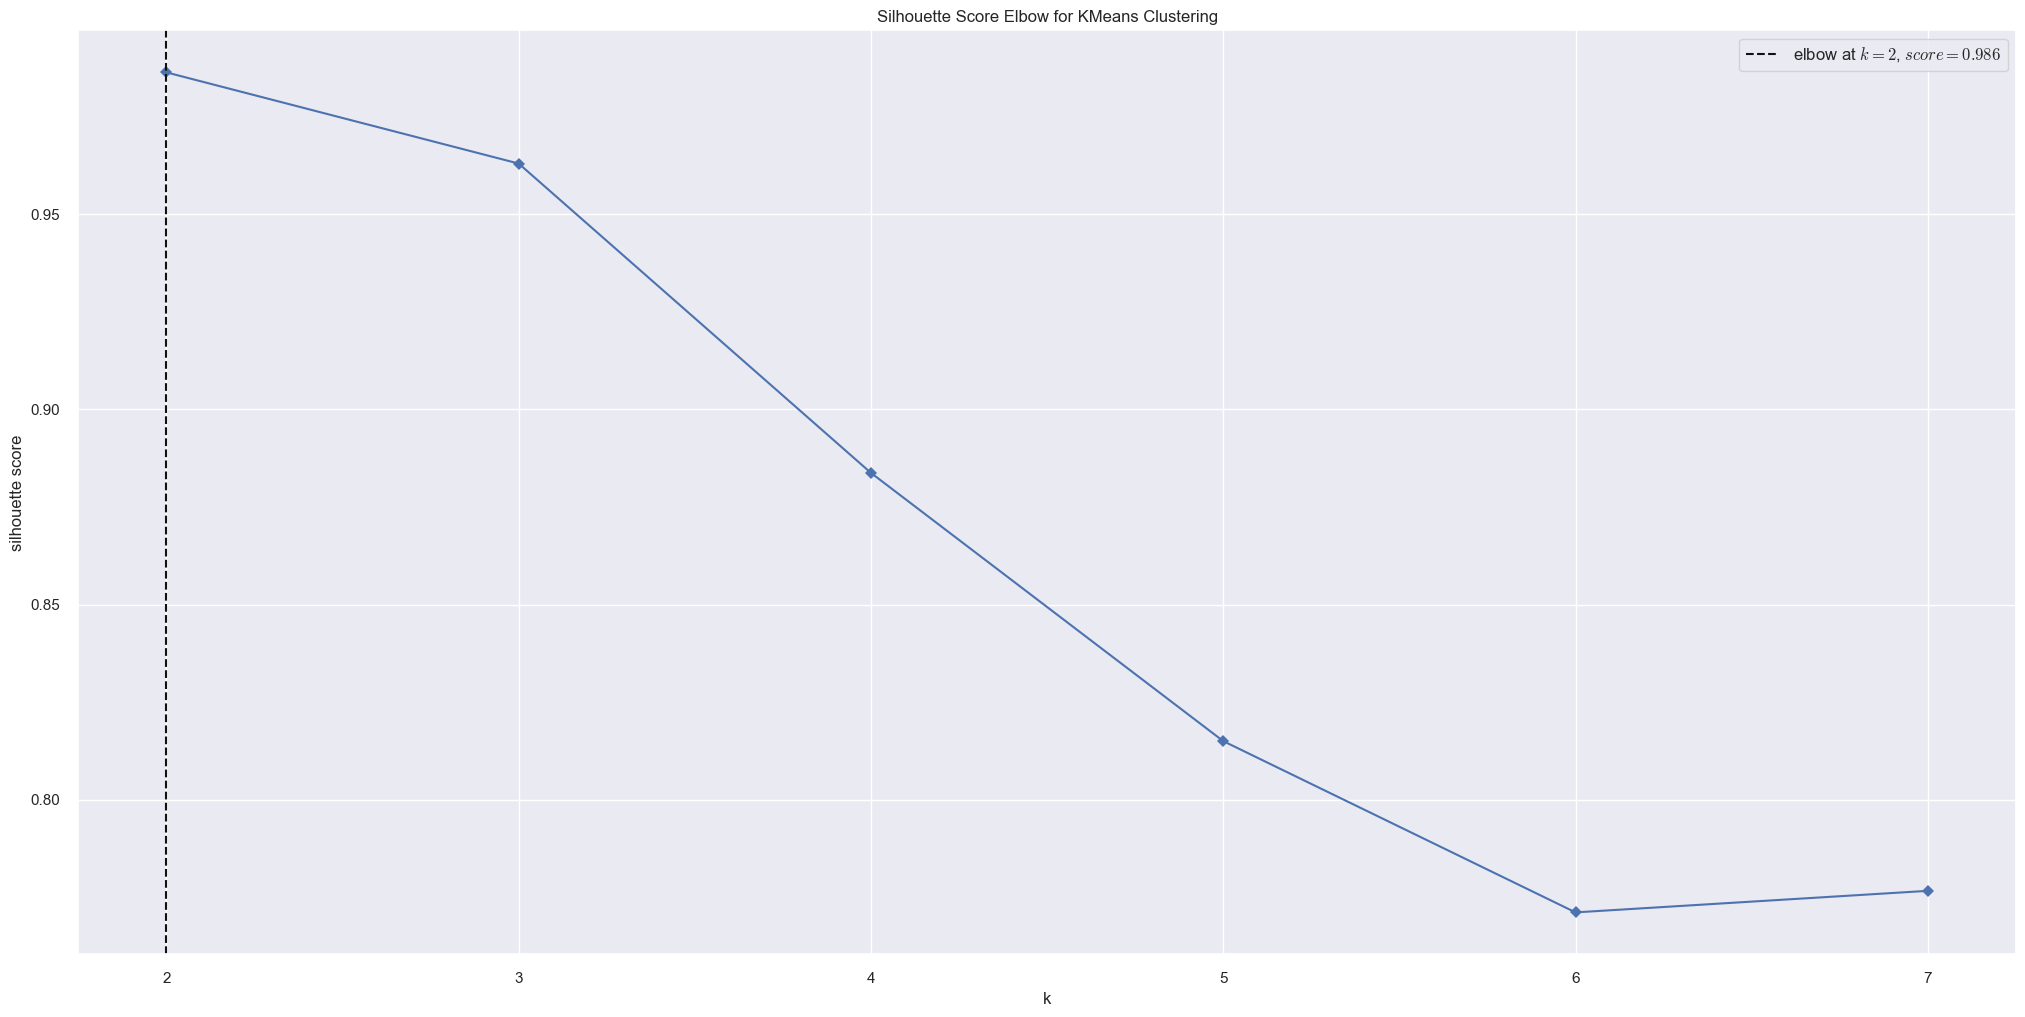

In [68]:


kmeans = KElbowVisualizer( c.KMeans(), k=cluster, metric='silhouette', timings=False );
kmeans.fit( X );
kmeans.show();

## 7.3 Silhouette Analysis

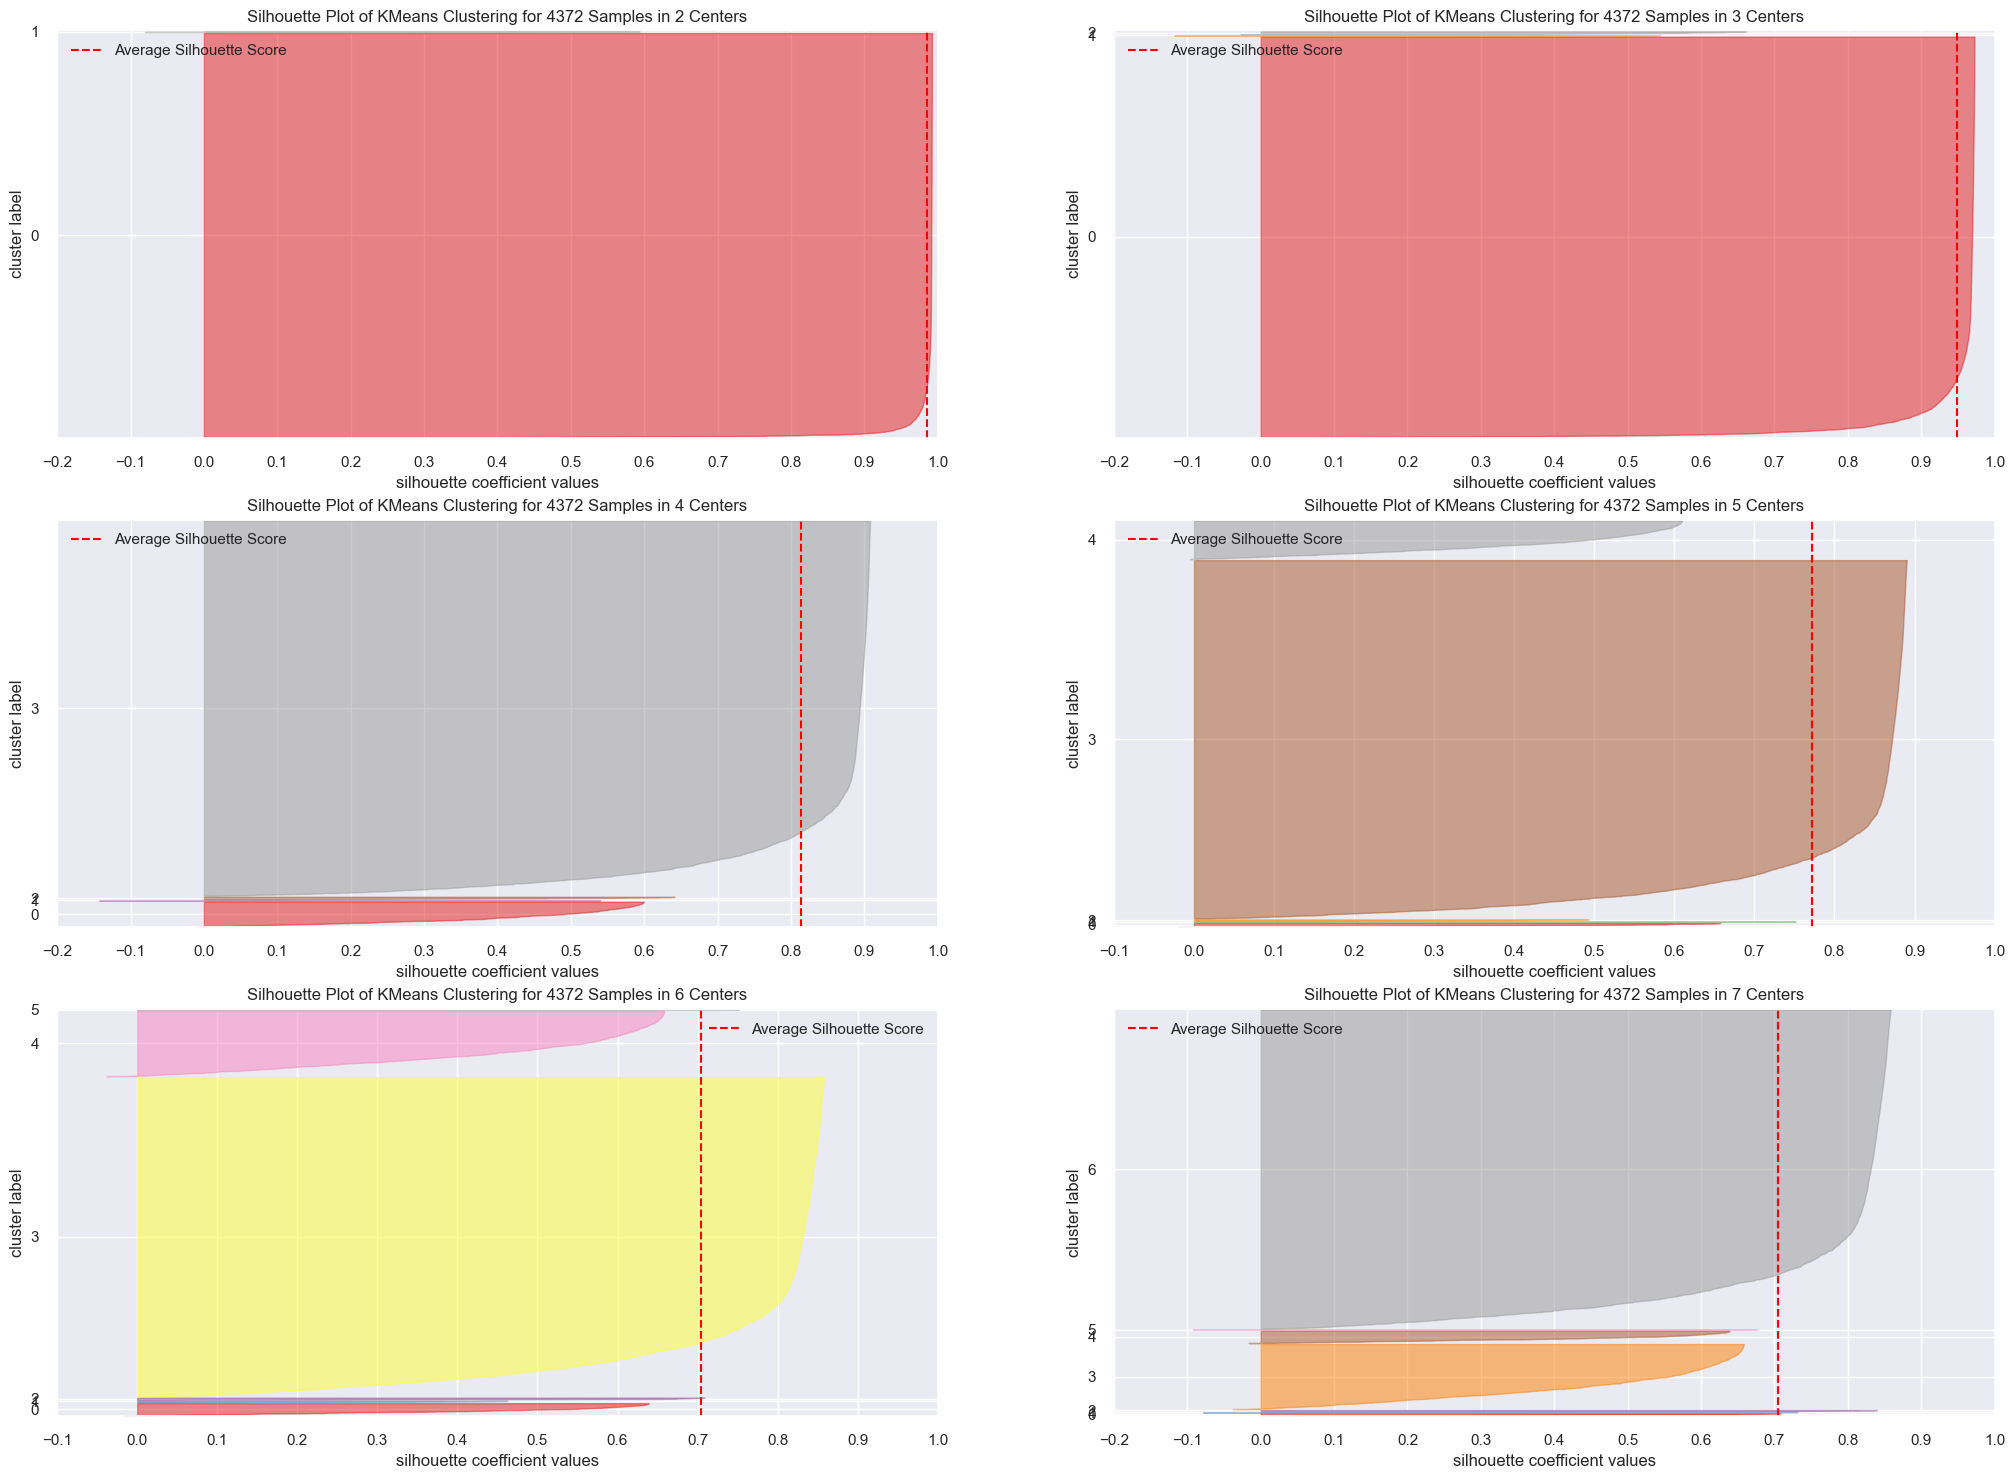

In [70]:
fig, ax = plt.subplots(3, 2, figsize=(25, 18))

for k in cluster:
    km = c.KMeans( n_clusters=k, init='random', n_init=10, max_iter=100, random_state=42 )
    q, mod = divmod(k, 2)
    visualizer = SilhouetteVisualizer( km, color='yellowbrick', ax=ax[q-1][mod])
    visualizer.fit( X )
    visualizer.finalize()


# 8 - MACHINE LEARNING TRAINING

In [71]:
# Model Definition
k = 4
kmeans = c.KMeans( init='random', n_clusters=k, n_init=10, max_iter=300, random_state=42 )

# Model Training
kmeans.fit( X )

# Model Prediction
labels = kmeans.labels_

## 8.1 - Cluster Validation

In [96]:
# WSS
print('WSS value: {}'. format( kmeans.inertia_) )

# Silhouette Score
print( 'SS Score: {}'.format( mt.silhouette_score( X, labels, metric='euclidean' ) ) )

WSS value: 40056506734.60249
SS Score: 0.8139972028952444


# 9 - CLUSTER ANALYSIS

In [ ]:
df9 = df6.copy()
df9['cluster'] = labels
df9.head()

## 9.1 - Vizualization Inspection


c:\Users\perot\anaconda3\envs\pa_clustering\lib\site-packages\sklearn\base.py:464: UserWarning:

X does not have valid feature names, but KMeans was fitted with feature names



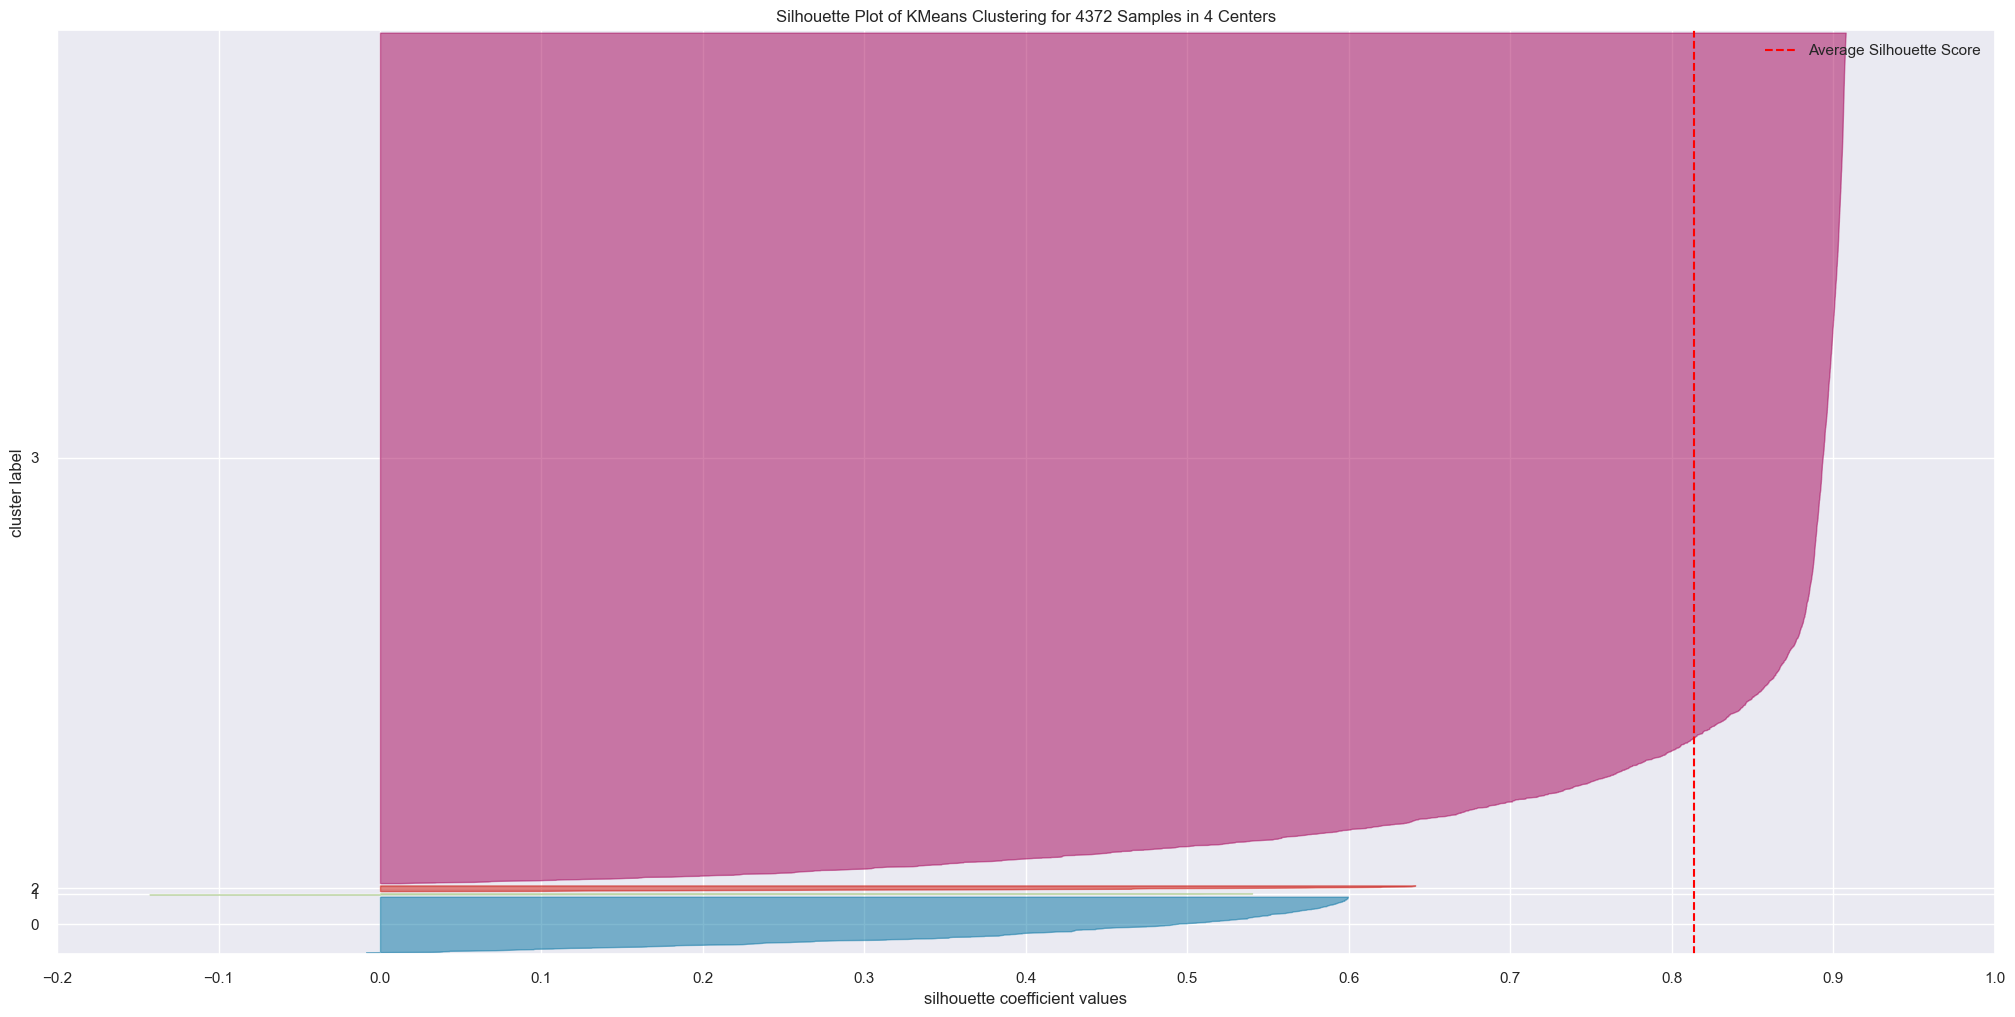

In [74]:
## Silhouette 4 clusters
visualizer = SilhouetteVisualizer( kmeans, colors='yellowbrick' )
visualizer.fit( X )
visualizer.finalize()

In [75]:
fig = px.scatter_3d( df9, x='recency_days', y='invoice_no', z='gross_revenue', color='cluster')
fig.show()

## 9.2 - 2D Plot

In [78]:
df9.head()

,customer_id,gross_revenue,recency_days,invoice_no,avg_ticket,cluster
0,17850,5288.63,302,35,16.950737,0
1,13047,3079.10,31,18,15.709694,3
2,12583,7187.34,2,18,28.634821,0
3,13748,948.25,95,5,33.866071,3
4,15100,635.10,330,6,105.850000,3


c:\Users\perot\anaconda3\envs\pa_clustering\lib\site-packages\seaborn\axisgrid.py:118: UserWarning:

The figure layout has changed to tight



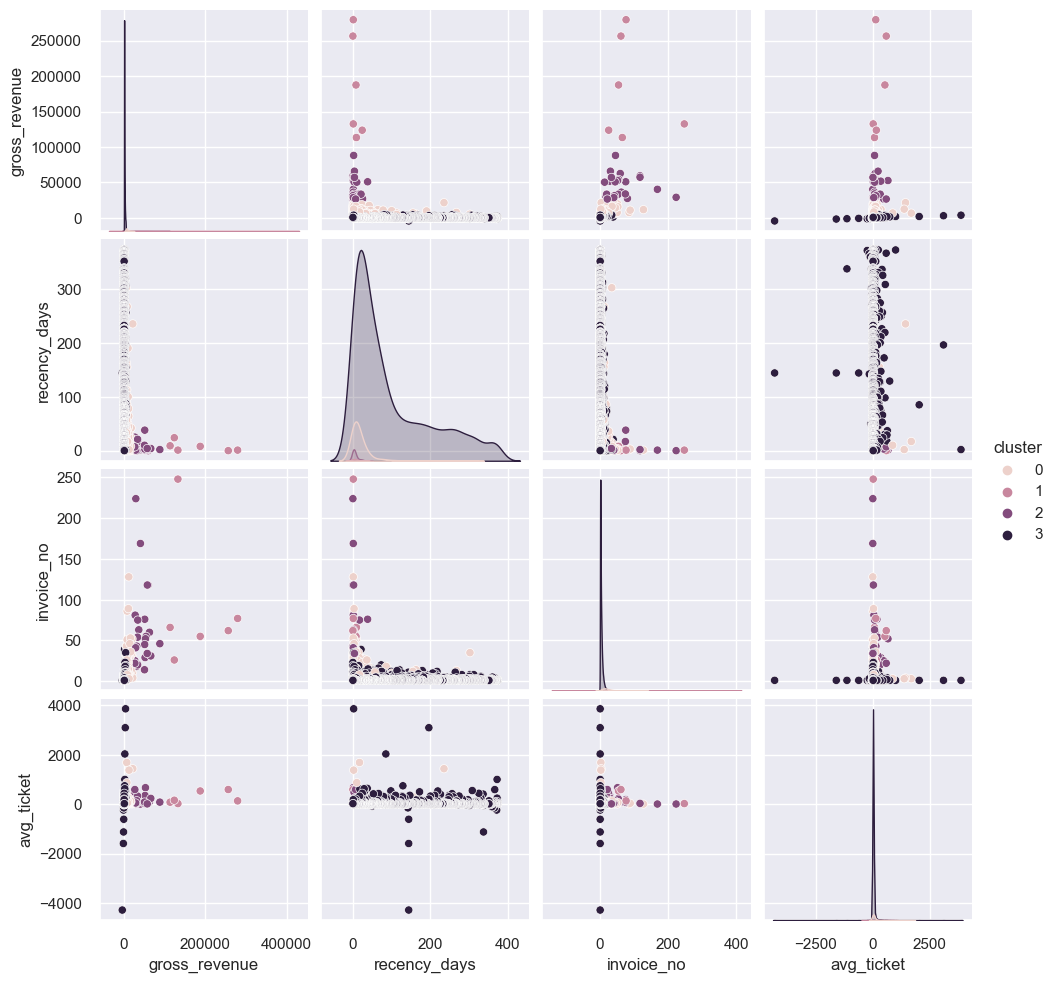

In [79]:
df_viz = df9.drop( columns='customer_id', axis=1)
sns.pairplot( df_viz, hue='cluster')

## 9.3 - UMAP|

In [ ]:
Machine Learning - Manifold

Aprendizado por topologia: PCA - Metodo baseado em matriz ou espaco entre distancias. Temos 9 condicoes, cumprir 9 colorarios para ter uma garantia de espaco. Espaco de Hilbert, etc.AffinityPropagation

UMAP, T-SNE ( 2009 )- Abordagem por topologia ( Manifold ). Topologia sao grafos em alta dimensionalidade

<Axes: xlabel='embedding_x', ylabel='embedding_y'>

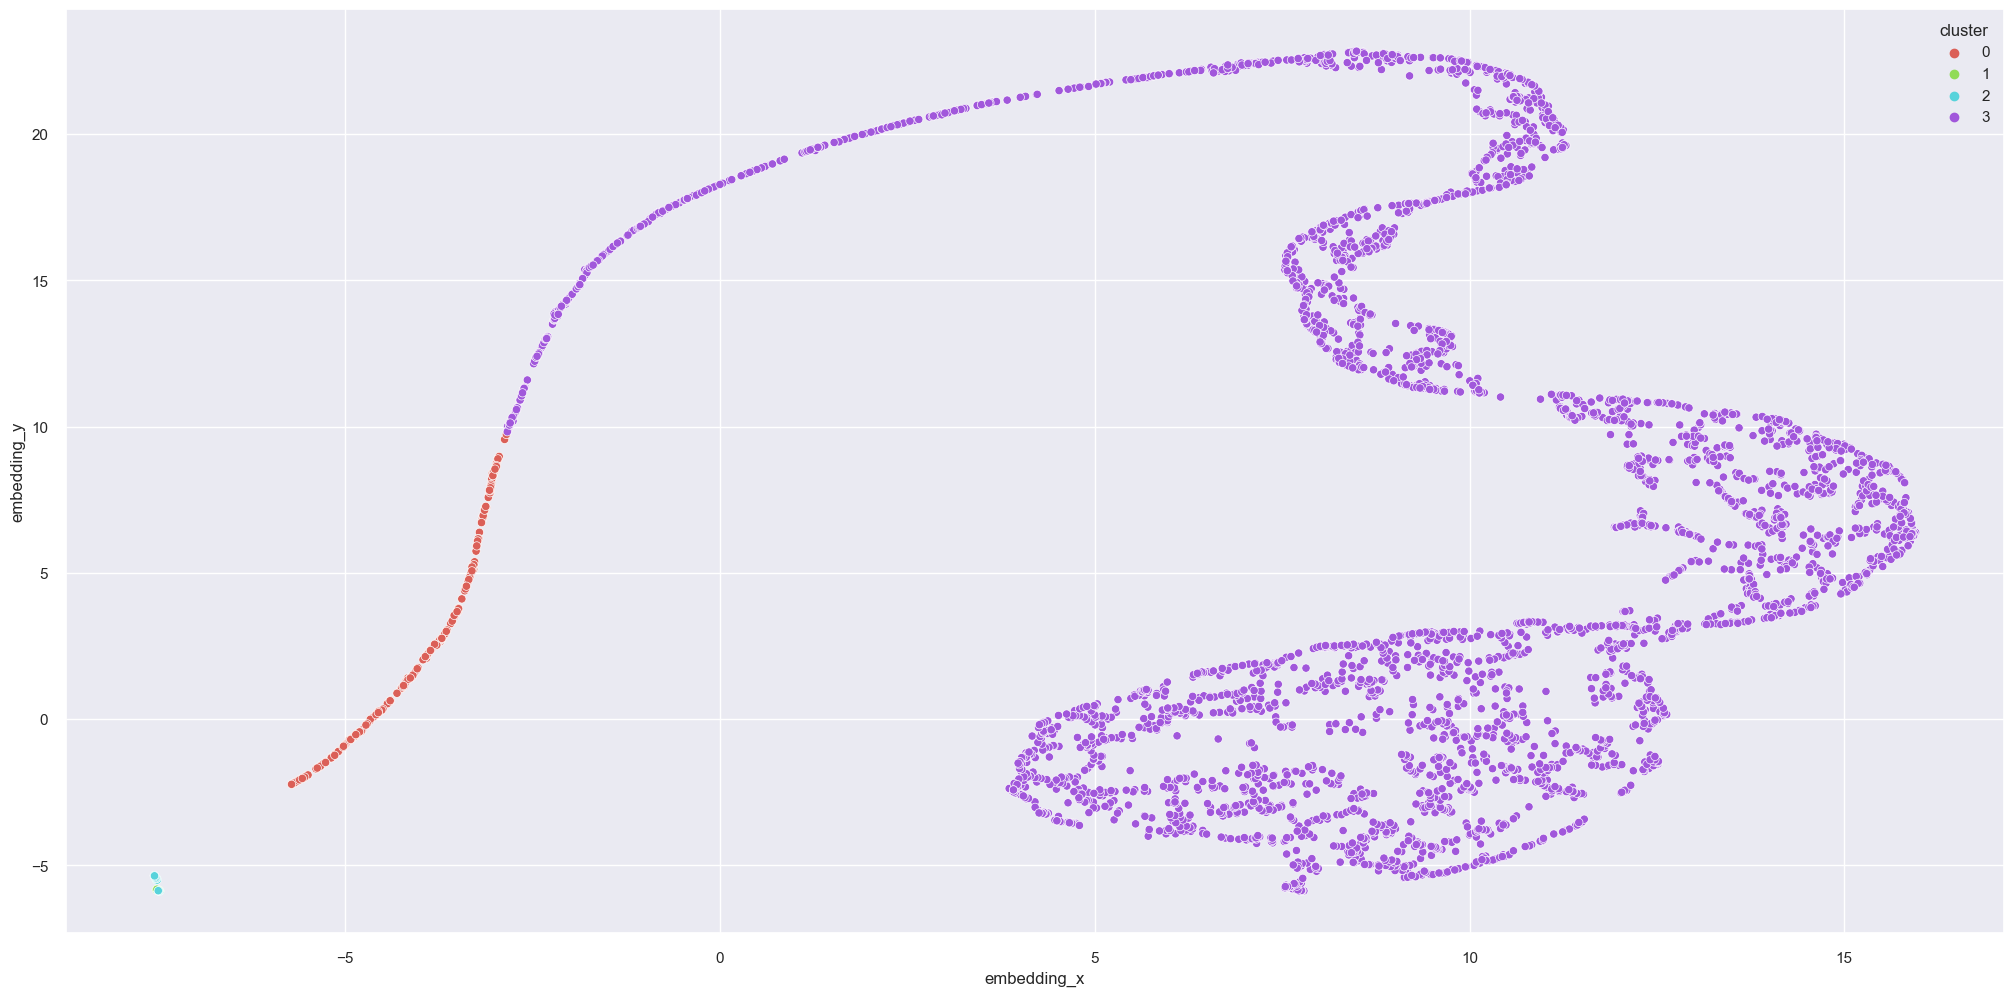

In [91]:
# UMAP 
reducer = umap.UMAP( n_neighbors=20, random_state=42 )
embedding = reducer.fit_transform( X )

# Embedding 
df_viz['embedding_x'] = embedding[:, 0]
df_viz['embedding_y'] = embedding[:, 1]

# Plot UMAP
sns.scatterplot( 
                 x='embedding_x',
                 y='embedding_y', 
                 hue='cluster',
                 palette=sns.color_palette('hls',
                                           n_colors=len(df_viz['cluster'].unique())),
                 data=df_viz)
                                           


## 9.4 - Cluster Profile

In [94]:
# Number of Customer
df_cluster = df9[['customer_id', 'cluster']].groupby('cluster').count().reset_index()
df_cluster['perc_customer'] = 100*( df_cluster['customer_id'] / df_cluster['customer_id'].sum() )

# Avg Gross Revenue
df_avg_gross_revenue = df9[['gross_revenue', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_avg_gross_revenue, how='inner', on='cluster')

# Avg Recency Days
df_avg_recency_days = df9[['recency_days', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_avg_recency_days, how='inner', on='cluster')

# Avg invoice_no
df_invoice_no = df9[['invoice_no', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_invoice_no, how='inner', on='cluster')

# Avg Ticket
df_avg_ticket = df9[['avg_ticket', 'cluster']].groupby('cluster').mean().reset_index()
df_cluster = pd.merge( df_cluster, df_avg_ticket, how='inner', on='cluster')


In [95]:
df_cluster.head()

,cluster,customer_id,perc_customer,gross_revenue,recency_days,invoice_no,avg_ticket
0,0,267,6.107045,8089.028652,20.280899,19.528090,62.783157
1,1,6,0.137237,182181.981667,7.166667,89.000000,253.626345
2,2,28,0.640439,42614.387143,6.178571,57.821429,162.862605
3,3,4071,93.115279,946.696250,96.969295,3.641120,25.359654


# 10 - DEPOLOY